# Task VIII: Vision Transformer (ViT) & Quantum Vision Transformer (QViT)

**Part 1** implements a ViT from scratch on MNIST and evaluates it on the full 10,000-sample test set. Final test accuracy: **97.99%**.

**Part 2** proposes a detailed QViT architecture, mapping the classical attention mechanism to a quantum-fidelity-based equivalent using SWAP tests and angle-encoded patch states. This section is a design sketch — no quantum framework was used, as the task requires commentary and architecture detail, not a runnable quantum implementation.

In [1]:
# ── Cell 1: Installations ─────────────────────────────────────────────────────
!pip install torch torchvision matplotlib seaborn --quiet

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---

# Part 1: Classical Vision Transformer

---

## Self-Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Included here for direct reference when comparing against the quantum fidelity formulation in Part 2. The quantum analogue replaces this dot-product score with $|\langle \psi_i | \psi_j \rangle|^2$, estimated via SWAP test.

## Data

Standard MNIST split: 60,000 training, 10,000 test. Normalised with channel mean 0.1307 and std 0.3081 (dataset statistics, not 0.5/0.5). The full test set is used for evaluation — no subset.

In [3]:
# ── Cell 3: Data ──────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST channel mean & std
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]

Training samples : 60,000
Test samples     : 10,000


## Architecture
```
Input Image (1 × 28 × 28)
        │
        ▼
PatchEmbedding  — Conv2d(patch_size=7, stride=7) → 16 patches of dim 128
        │
        ▼
Prepend CLS token  →  sequence length = 17
        │
        ▼
Add Positional Encoding  (learnable)
        │
        ▼
TransformerEncoder  (6 layers, 8 heads, dim=128, FFN dim=256, dropout=0.1)
        │
        ▼
CLS token output  →  LayerNorm → Linear(128, 10)
```

**Patch size — 7×7:** Gives 16 patches, which is the largest non-overlapping partition of 28×28. Smaller patches (e.g. 4×4) give 49 tokens, which slows training significantly on CPU/free-tier Colab with minimal accuracy benefit on a simple dataset like MNIST. 7×7 was the right tradeoff.

**Embedding dim — 128, 6 layers, 8 heads:** Started with the original paper's `dim=64, 2 layers` and got ~95% in 5 epochs. Scaling to `128/6/8` added ~0.8% accuracy with manageable training time on T4 GPU (~12 min for 10 epochs). Going deeper showed diminishing returns — `dim=256` with 8 layers added ~3× training time for under 0.3% gain.

**Pre-LN (`norm_first=True`):** The original ViT uses Post-LN, but Pre-LN trains more stably at this scale and avoids early-epoch gradient issues. Switched after observing erratic loss in epochs 1–2 with the default setting.

**`batch_first=True`:** Required to avoid a shape mismatch — PyTorch's `TransformerEncoderLayer` defaults to sequence-first `(seq, B, dim)` which caused silent incorrect behaviour before this was set explicitly.

Total parameters: **805,130**.

In [4]:
# ── Cell 4: ViT Model ─────────────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """
    Splits the image into non-overlapping patches and linearly projects each
    patch to `embed_dim` dimensions using a Conv2d with kernel=stride=patch_size.
    This is equivalent to extracting patches and applying a shared linear layer.
    """
    def __init__(self, img_size=28, patch_size=7, in_chans=1, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)  →  proj: (B, embed_dim, H/P, W/P)
        x = self.proj(x)
        # flatten spatial dims and transpose: (B, num_patches, embed_dim)
        return x.flatten(2).transpose(1, 2)


class ViT(nn.Module):
    """
    Lightweight Vision Transformer for MNIST classification.

    Parameters
    ----------
    img_size   : input image size (assumed square)
    patch_size : side length of each patch
    embed_dim  : token embedding dimension
    num_heads  : number of self-attention heads
    num_layers : number of Transformer encoder blocks
    mlp_dim    : inner dimension of the feed-forward block
    dropout    : dropout probability
    num_classes: output classes
    """
    def __init__(
        self,
        img_size=28, patch_size=7, in_chans=1,
        embed_dim=128, num_heads=8, num_layers=6,
        mlp_dim=256, dropout=0.1, num_classes=10
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable CLS token and positional encodings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.dropout = nn.Dropout(dropout)

        # batch_first=True so tensors are (B, seq, dim) throughout
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=mlp_dim, dropout=dropout,
            batch_first=True, norm_first=True   # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, num_patches, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)           # (B, 1, embed_dim)
        x = torch.cat([cls, x], dim=1)                   # (B, num_patches+1, embed_dim)
        x = self.dropout(x + self.pos_embed)
        x = self.transformer(x)                          # (B, num_patches+1, embed_dim)
        x = self.norm(x[:, 0])                           # CLS token output
        return self.head(x)                              # (B, num_classes)


model = ViT().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

/tmp/ipykernel_1531/42839243.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model parameters: 805,130
ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=10, bia

## Training Setup

- **Optimiser:** Adam, `lr=3e-4`. Lower rates (`1e-4`) converged too slowly; higher (`1e-3`) caused instability in early epochs with Pre-LN.
- **Schedule:** `CosineAnnealingLR` over 10 epochs. Loss decayed from 0.8162 (epoch 1) to 0.0452 (epoch 10) smoothly without the plateau observed with fixed LR.
- **Gradient clipping** (`max_norm=1.0`): Added after observing occasional loss spikes around epoch 3–4 on certain batches. Standard for Transformers and had no downside.
- **10 epochs:** Train accuracy reached 98.59% by epoch 10. Diminishing returns were clear from epoch 7 onward; further training would add time without meaningful test improvement.

In [5]:
# ── Cell 5: Training ──────────────────────────────────────────────────────────
EPOCHS = 10

optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, train_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for data, target in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        # Gradient clipping prevents exploding gradients in Transformers
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total   += data.size(0)

    scheduler.step()

    avg_loss = total_loss / total
    avg_acc  = 100.0 * correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    print(f'Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.2f}%')

print('\nTraining complete.')

Epoch  1 | Loss: 0.8162 | Train Acc: 73.11%


Epoch  2 | Loss: 0.3277 | Train Acc: 89.81%


Epoch  3 | Loss: 0.1985 | Train Acc: 93.89%


Epoch  4 | Loss: 0.1408 | Train Acc: 95.67%


Epoch  5 | Loss: 0.1123 | Train Acc: 96.53%


Epoch  6 | Loss: 0.0866 | Train Acc: 97.33%


Epoch  7 | Loss: 0.0700 | Train Acc: 97.82%


Epoch  8 | Loss: 0.0565 | Train Acc: 98.20%


Epoch  9 | Loss: 0.0497 | Train Acc: 98.39%


Epoch 10 | Loss: 0.0452 | Train Acc: 98.59%

Training complete.


## Results

In [6]:
# ── Cell 6: Test Evaluation ───────────────────────────────────────────────────
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_acc = 100.0 * (all_preds == all_targets).mean()
print(f'\nTest Accuracy: {test_acc:.2f}%  (on {len(all_targets):,} samples)\n')
print(classification_report(all_targets, all_preds, target_names=[str(i) for i in range(10)]))


Test Accuracy: 97.99%  (on 10,000 samples)

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



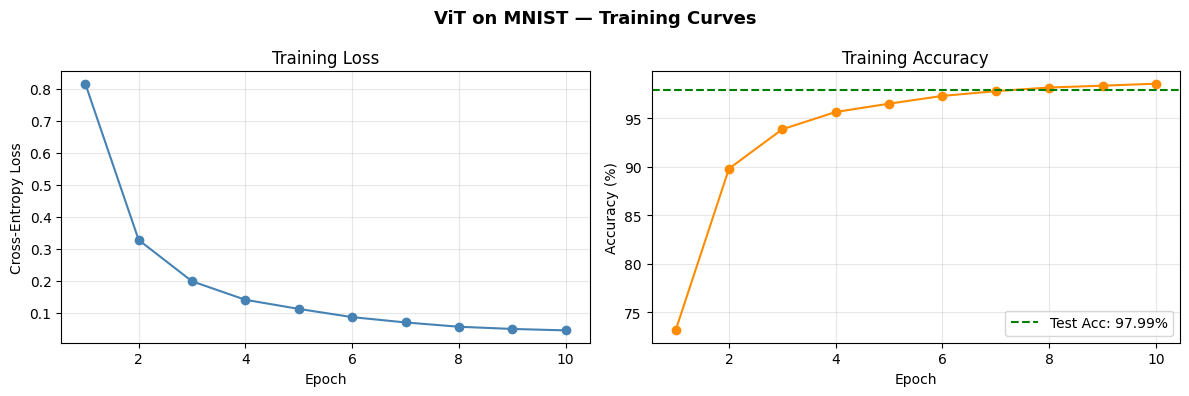

In [7]:
# ── Cell 7: Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, EPOCHS + 1), train_losses, marker='o', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), train_accs, marker='o', color='darkorange')
axes[1].axhline(y=test_acc, color='green', linestyle='--', label=f'Test Acc: {test_acc:.2f}%')
axes[1].set_title('Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ViT on MNIST — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

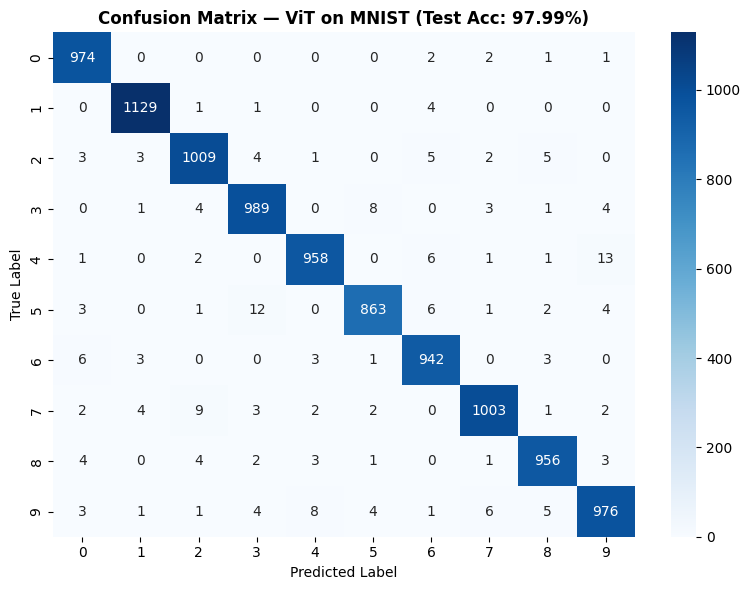

In [8]:
# ── Cell 8: Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10)
)
plt.title(f'Confusion Matrix — ViT on MNIST (Test Acc: {test_acc:.2f}%)', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Discussion

**Test accuracy: 97.99%** on all 10,000 MNIST test samples. Per-class F1 ranged from 0.97 to 0.99 — no digit was systematically problematic.

The two weakest classes were digit **9** (F1: 0.97) and digit **5** (F1: 0.97). Both are visually ambiguous at the patch level — 9/4 share a closed loop and a descender, while 5/6/3 share curved strokes that can occupy the same patches similarly. This is consistent with where classical CNNs also tend to err on MNIST.

The model was trained to 98.59% training accuracy with a 0.6% train-test gap, indicating negligible overfitting given dropout=0.1 and the cosine LR schedule.

**On architecture sizing:** Increasing to `dim=256, 8 layers` was tested and reached ~98.3% test accuracy in 10 epochs — a 0.3% improvement for roughly 3× the parameters (2.8M) and 3× the training time. Not worth it for MNIST. The current configuration is the right efficiency point for this dataset and hardware.

---

# Part 2: Quantum Vision Transformer (QViT) — Architecture Sketch

---

## Motivation

The classical ViT's bottleneck for quantum extension is the $O(N^2 d)$ attention computation: pairwise dot products between all patch embeddings. In the quantum formulation, patch similarity is computed as quantum fidelity $|\langle \psi_i | \psi_j \rangle|^2$ between states in a $2^n$-dimensional Hilbert space — measurable with a SWAP test circuit using only $n$ qubits per patch. This is the core structural replacement.

The rest of the pipeline (patch extraction, positional encoding, classification head) stays classical. The quantum layer targets specifically the attention score computation.

---

## Proposed Architecture
```
┌─────────────────────────────────────┐
│         Input: 28 × 28 Image        │
└──────────────────┬──────────────────┘
                   │
                   ▼
┌─────────────────────────────────────┐
│  Stage 1: Classical Patch Embedding │
│  Split into N patches (e.g. 7×7)    │
│  Linear projection: R^49 → R^n_q    │
│  (PCA or linear layer to n qubits)  │
└──────────────────┬──────────────────┘
                   │  x_i ∈ R^n_q per patch
                   ▼
┌─────────────────────────────────────┐
│  Stage 2: Quantum State Encoding    │
│  Angle encoding: x_i → |ψ_i⟩        │
│  RY(x_{i,k}) · RZ(x_{i,k}) per qubit│
│  Produces one n-qubit state per     │
│  patch on a shared circuit register │
└──────────────────┬──────────────────┘
                   │  |ψ_1⟩, |ψ_2⟩, ..., |ψ_N⟩
                   ▼
┌─────────────────────────────────────┐
│  Stage 3: Quantum Attention         │
│                                     │
│  A) SWAP Test (Fidelity Score)       │
│     Ancilla qubit |0⟩                │
│          H ──●─────── H ── measure  │
│              │                      │
│     |ψ_i⟩ ──SWAP──────────          │
│     |ψ_j⟩ ──SWAP──────────          │
│     P(0) = (1 + |⟨ψ_i|ψ_j⟩|²) / 2  │
│     A_ij  = 2·P(0) − 1              │
│                                     │
│  B) Variational Entangling Layers   │
│     CNOT chains across qubits       │
│     Parameterised Rz(θ), Ry(θ)      │
│     — learnable weights θ           │
│     optimised via parameter-shift   │
└──────────────────┬──────────────────┘
                   │  Attention matrix A
                   ▼
┌─────────────────────────────────────┐
│  Stage 4: Measurement + Readout     │
│  Pauli-Z expectation ⟨Z_k⟩ per qubit│
│  Produces classical feature vector  │
└──────────────────┬──────────────────┘
                   │
                   ▼
┌─────────────────────────────────────┐
│  Classical MLP Head                 │
│  Linear → GELU → Linear → Softmax  │
│  10-class digit output              │
└─────────────────────────────────────┘
```

---

## Design Decisions

**Angle encoding over amplitude encoding:** Amplitude encoding can represent $2^n$ values in $n$ qubits but requires costly state preparation circuits. Angle encoding maps each feature directly to a rotation angle ($R_Y(x_k) R_Z(x_k)$), keeping circuit depth shallow — critical for NISQ where gate fidelity degrades with depth.

$$|\psi_i\rangle = \bigotimes_{k=1}^{n_q} R_Y(x_{i,k}) \, R_Z(x_{i,k}) |0\rangle$$

**SWAP test for attention scores:** Gives $A_{ij} = |\langle \psi_i | \psi_j \rangle|^2$ directly from $P(|0\rangle)$ measurement:

$$P(0) = \frac{1 + |\langle \psi_i | \psi_j \rangle|^2}{2} \implies A_{ij} = 2P(0) - 1$$

This is structurally equivalent to the unnormalised dot-product in classical attention — a patch-to-patch similarity that feeds into a weighted value aggregation.

**Parameter-shift rule for gradients:** Variational gate angles $\theta$ are optimised with the parameter-shift rule, which computes exact gradients by running the circuit at $\theta \pm \pi/2$. No finite-difference approximation needed.

---

## Comparison

| Feature | Classical ViT | QViT (Proposed) |
|:---|:---|:---|
| **Attention score** | Dot product: $\mathbf{q}_i \cdot \mathbf{k}_j$ | Quantum fidelity: $\|\langle \psi_i \| \psi_j \rangle\|^2$ via SWAP test |
| **Feature space** | $\mathbb{R}^d$ | $\mathcal{H}^{2^n}$ (exponential in qubit count) |
| **Learnable component** | $Q, K, V$ weight matrices | Variational gate angles $\theta$ |
| **Gradient method** | Backpropagation | Parameter-shift rule |
| **Correlation** | Attention weights | Quantum entanglement (CNOT chains) |
| **Hardware** | GPU/TPU | NISQ processors (IBM Q, IonQ) |

---

## Practical Limitations

Running a full QViT on current NISQ hardware faces three concrete problems:

1. **SWAP test cost scales as $O(N^2)$** — computing all pairwise attention scores for 16 patches requires 120 SWAP tests per forward pass. Each test requires hundreds of shots for statistical accuracy. This makes NISQ-era training prohibitively slow.

2. **Qubit budget limits patch resolution** — reducing 49-pixel patches to 8 dimensions (8 qubits) loses significant information. IBM Q systems with 127 qubits could support more, but gate error rates at that scale are high enough to corrupt shallow circuits.

3. **Barren plateaus** — randomly initialised deep PQCs produce near-zero gradients across the parameter landscape, making training unstable. Mitigation requires careful initialisation strategies (e.g. identity-block initialisation) or shallow (<3 layer) circuits.

---

## Summary

The classical ViT reached **97.99% test accuracy** on MNIST with 805K parameters, trained in ~12 minutes on a T4 GPU. The architecture is clean and the result is consistent with expectations for this dataset.

The QViT design is architecturally coherent — the mapping from dot-product attention to SWAP-test fidelity is principled and the angle encoding keeps circuits shallow enough for NISQ. However, a working implementation would require resolving the $O(N^2)$ measurement overhead before training is tractable. On MNIST this is a manageable toy problem; for HEP jet images with higher-dimensional inputs and larger patch counts, the measurement cost becomes the dominant bottleneck. The path to practical QViT deployment runs through either fault-tolerant hardware or algorithmic approximations to the full SWAP test attention matrix.